In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

## Bulk

In [2]:
pretrain_bulk = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/bulk/pretraining_bulk_RAW.h5ad")

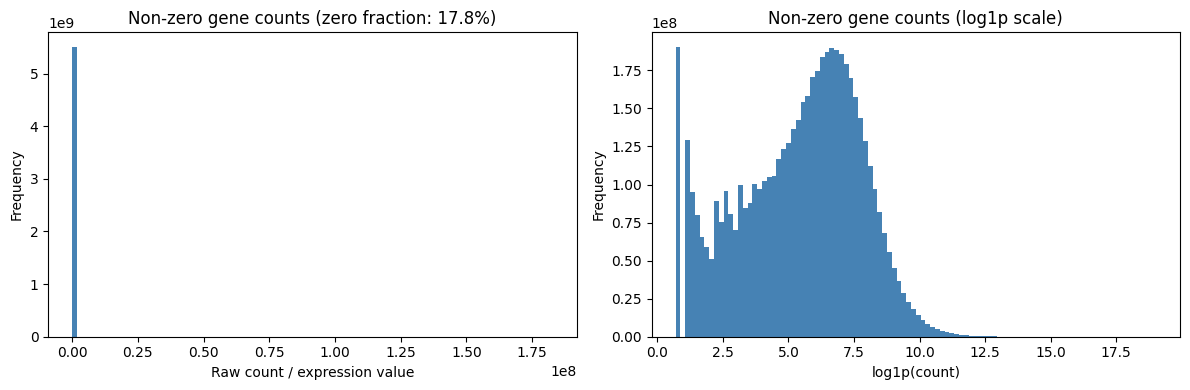

Sparsity: 17.8%
Non-zero value stats: min=1.00, median=313.00, max=182754896.00
Fraction that are exactly 1: 3.5%


In [3]:
# Extract non-zero values from sparse matrix
if sparse.issparse(pretrain_bulk.X):
    vals = pretrain_bulk.X.data  # only non-zero entries
else:
    vals = pretrain_bulk.X[pretrain_bulk.X > 0].ravel()

zero_frac = 1 - (len(vals) / (pretrain_bulk.n_obs * pretrain_bulk.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

# Log scale on x-axis — more informative for bulk TPM
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")


In [3]:
pretrain_bulk.X.mean(axis = 1).mean()

1428.2859

[10720 11289 11217 11148 11335 11371 11396 11412 11530 11197]
mean: 9836.628308928572
median: 10689.0
min: 200
max: 11961


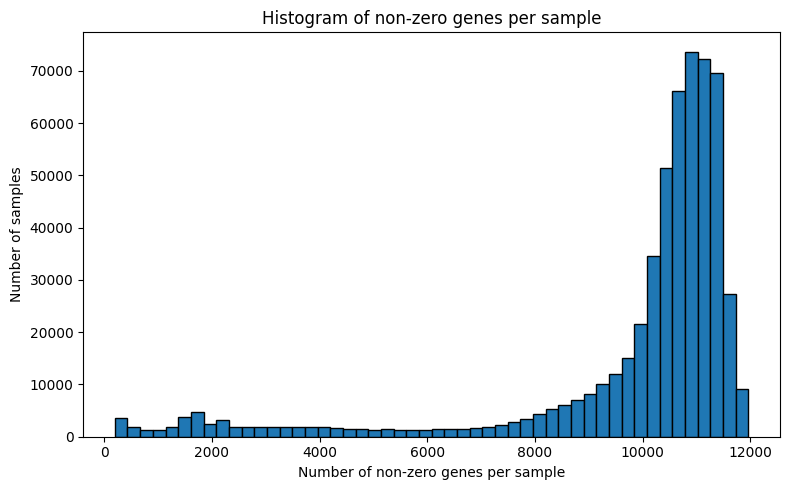

In [6]:
X = pretrain_bulk.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

### Bulk - GTEx

In [7]:
pretrain_bulk_gtex = pretrain_bulk.copy()[pretrain_bulk.obs["dataset"] == "GTEx"]

In [8]:
pretrain_bulk_gtex.X.mean(axis = 1).mean()

3736.3965

[10720 11289 11217 11148 11335 11371 11396 11412 11530 11197]
mean: 11342.134088134088
median: 11376.0
min: 10083
max: 11919


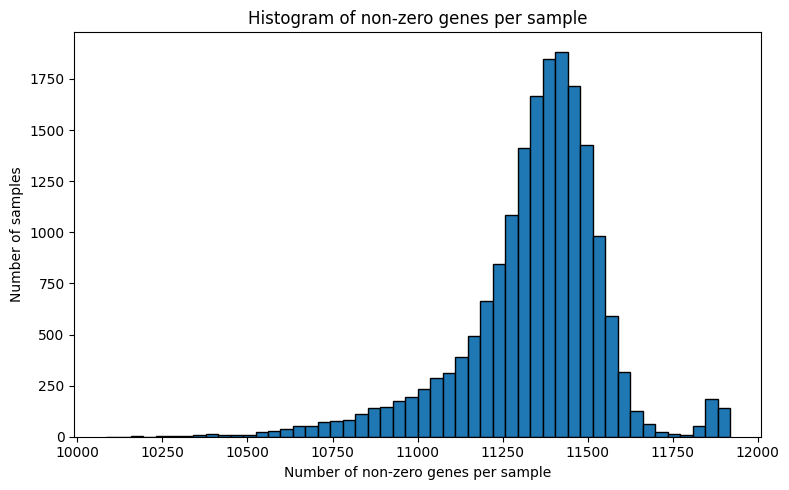

In [11]:
X = pretrain_bulk_gtex.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

### Bulk - ARCHS4

In [13]:
pretrain_bulk_archs4 = pretrain_bulk.copy()[pretrain_bulk.obs["dataset"] == "ARCHS4"]

In [14]:
pretrain_bulk_archs4.X.mean(axis = 1).mean()

1351.554

In [15]:
pretrain_bulk_archs4.X.getnnz(axis=1).mean()

9786.578301493408

[10192 10225 10287 10230 10220  3023  3429  3484  2853  2984]
mean: 9786.578301493408
median: 10658.0
min: 200
max: 11961


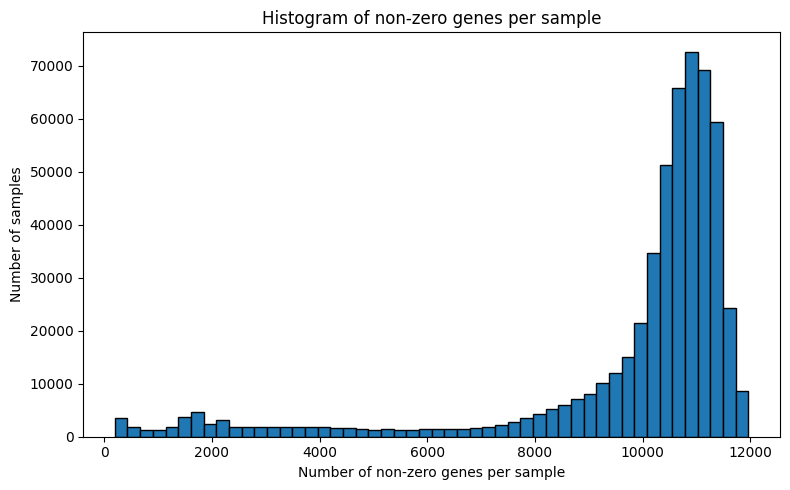

In [17]:
X = pretrain_bulk_archs4.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [18]:
# SC

In [4]:
pretrain_sc = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/sc/pretraining_sc_RAW.h5ad")

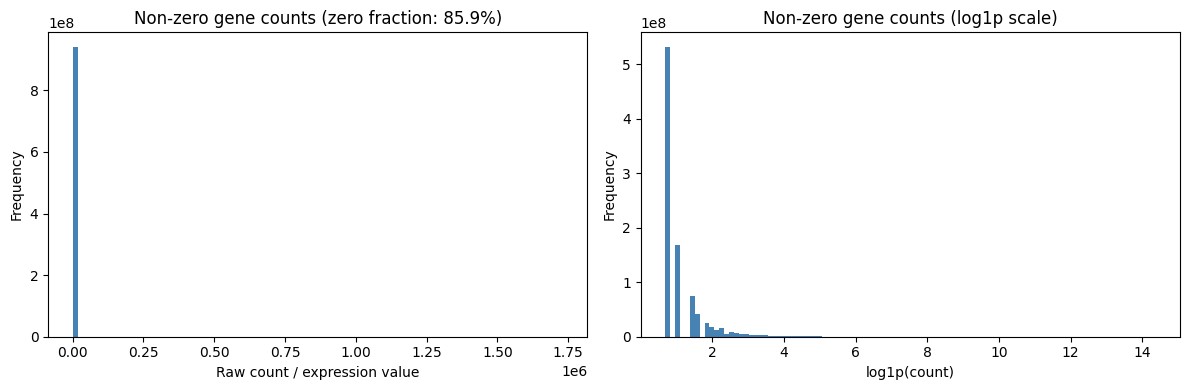

Sparsity: 85.9%
Non-zero value stats: min=1.00, median=1.00, max=1730805.00
Fraction that are exactly 1: 56.5%


In [5]:
# Extract non-zero values from sparse matrix
if sparse.issparse(pretrain_sc.X):
    vals = pretrain_sc.X.data  # only non-zero entries
else:
    vals = pretrain_sc.X[pretrain_.X > 0].ravel()

zero_frac = 1 - (len(vals) / (pretrain_sc.n_obs * pretrain_sc.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

# Log scale on x-axis — more informative for sc TPM
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [20]:
pretrain_sc.X.mean(axis = 1).mean()

0.6804685

In [21]:
pretrain_sc.X.getnnz(axis=1).mean()

1681.4283821428571

[1242  435  539  537 1153 1952 1087 1492 1628 1428]
mean: 1681.4283821428571
median: 1346.0
min: 200
max: 10850


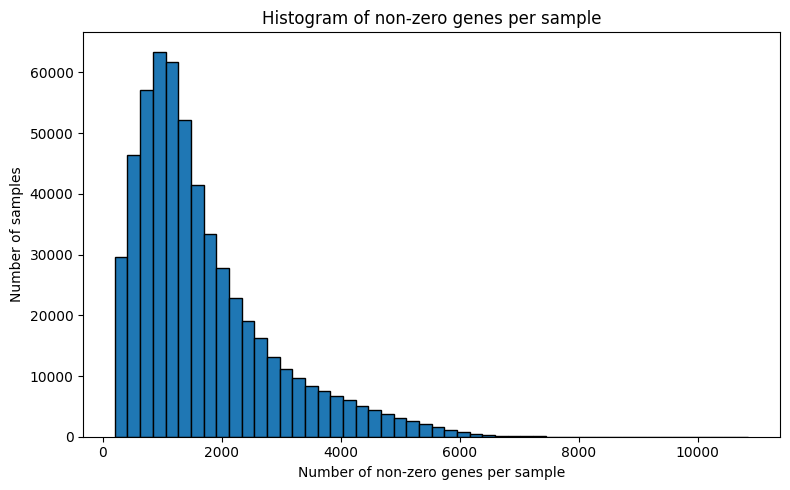

In [23]:
X = pretrain_sc.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

## Cancer classification (5 types) - TCGA

In [10]:
tcga = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/TCGA/tcga.h5ad")

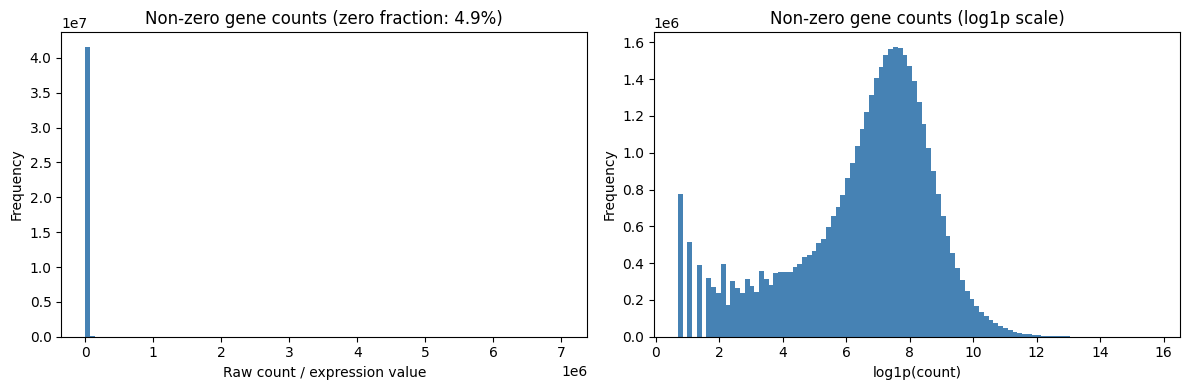

Sparsity: 4.9%
n_obs=3666, n_vars=11964
Non-zero value stats: min=1.00, median=1122.00, max=7032374.00
Fraction that are exactly 1: 1.9%


In [11]:
cohorts = {"TCGA-BRCA", "TCGA-BLCA", "TCGA-GBM", "TCGA-LGG", "TCGA-LUAD", "TCGA-UCEC"}
mask = tcga.obs["project_id"].astype(str).isin(cohorts)
tcga = tcga[mask].copy()

# Filter to gene list
gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
keep_genes = tcga.var_names.isin(gene_list)
tcga = tcga[:, keep_genes].copy()

X = tcga.X
if sparse.issparse(X):
    vals = X.data
else:
    vals = X[X > 0].ravel()

zero_frac = 1 - (len(vals) / (tcga.n_obs * tcga.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={tcga.n_obs}, n_vars={tcga.n_vars}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")


In [12]:
tcga.X.mean(axis = 1).mean()

3253.296332373188

[11355 11458 11499 11411 11278 11178 11400 11562 11349 11469]
mean: 11382.095744680852
median: 11400.0
min: 10669
max: 11934


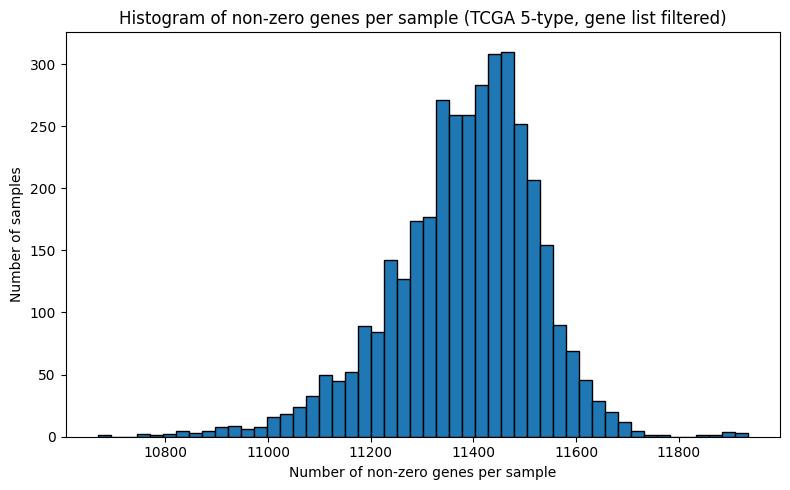

In [13]:
X = tcga.X
if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (TCGA 5-type, gene list filtered)")
plt.tight_layout()
plt.show()

del tcga

## Cancer classification (33 types) - TCGA

In [15]:
tcga = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/TCGA/tcga.h5ad")

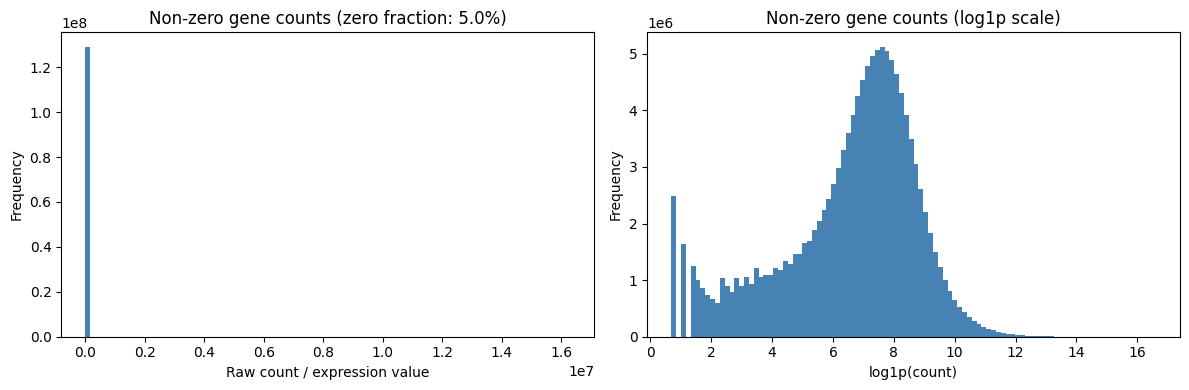

Sparsity: 5.0%
n_obs=11370, n_vars=11964
Non-zero value stats: min=1.00, median=1126.00, max=16292340.00
Fraction that are exactly 1: 1.9%


In [16]:
cohorts_33 = {
    "TCGA-ACC","TCGA-BLCA","TCGA-BRCA","TCGA-CESC","TCGA-CHOL","TCGA-COAD",
    "TCGA-DLBC","TCGA-ESCA","TCGA-GBM","TCGA-HNSC","TCGA-KICH","TCGA-KIRC",
    "TCGA-KIRP","TCGA-LAML","TCGA-LGG","TCGA-LIHC","TCGA-LUAD","TCGA-LUSC",
    "TCGA-MESO","TCGA-OV","TCGA-PAAD","TCGA-PCPG","TCGA-PRAD","TCGA-READ",
    "TCGA-SARC","TCGA-SKCM","TCGA-STAD","TCGA-TGCT","TCGA-THCA","TCGA-THYM",
    "TCGA-UCEC","TCGA-UCS","TCGA-UVM",
}
mask = tcga.obs["project_id"].astype(str).isin(cohorts_33)
tcga = tcga[mask].copy()

gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
tcga = tcga[:, tcga.var_names.isin(gene_list)].copy()

X = tcga.X
if sparse.issparse(X):
    vals = X.data
else:
    vals = X[X > 0].ravel()

zero_frac = 1 - (len(vals) / (tcga.n_obs * tcga.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")
plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={tcga.n_obs}, n_vars={tcga.n_vars}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [17]:
tcga.X.mean(axis = 1).mean()

3431.14529781811

[11433 11610 11507 11197 11595 11355 11458 11502 11416 11620]
mean: 11363.349516270888
median: 11381.0
min: 10350
max: 11954


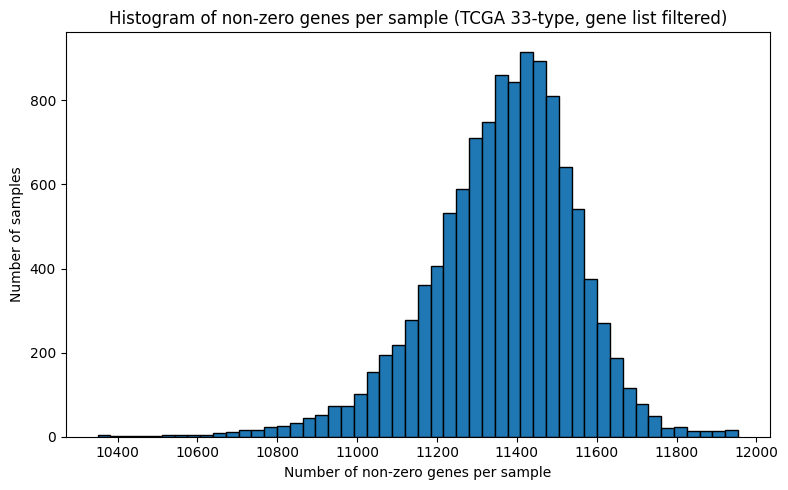

In [19]:
X = tcga.X
if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (TCGA 33-type, gene list filtered)")
plt.tight_layout()
plt.show()

del tcga

## Deconvolution - pseudo-bulk

In [2]:
pseudo_bulk = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/pseudo_bulk/pseudo_bulk_RAW.h5ad")

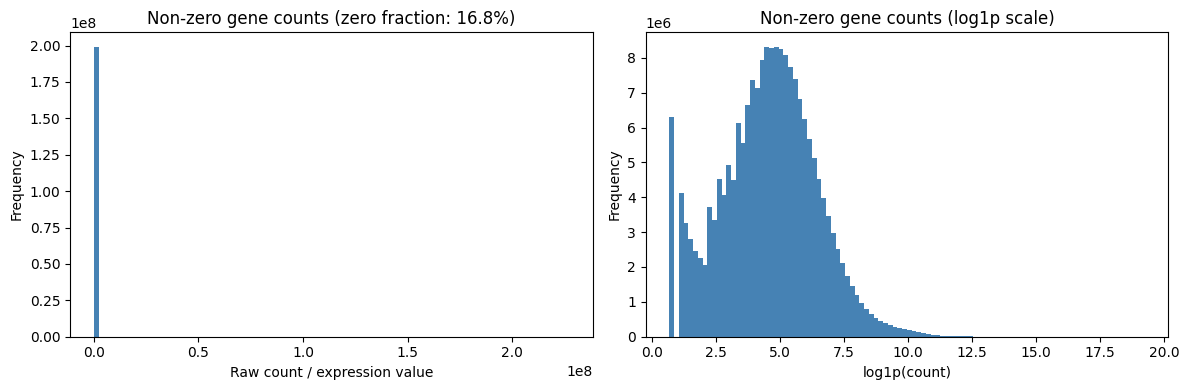

Sparsity: 16.8%
Non-zero value stats: min=1.00, median=102.00, max=226945472.00
Fraction that are exactly 1: 3.2%


In [3]:
# Extract non-zero values from sparse matrix
if sparse.issparse(pseudo_bulk.X):
    vals = pseudo_bulk.X.data  # only non-zero entries
else:
    vals = pretrain_pseudo_bulk.X[pseudo_bulk.X > 0].ravel()

zero_frac = 1 - (len(vals) / (pseudo_bulk.n_obs * pseudo_bulk.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

# Log scale on x-axis — more informative for pseudo bulk TPM
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")


In [26]:
pseudo_bulk.X.mean(axis = 1).mean()

655.86115

[10858 10974  9663 11017 10578  9775 10278  9588  8783 10911]
mean: 9957.69205
median: 10216.0
min: 289
max: 11930


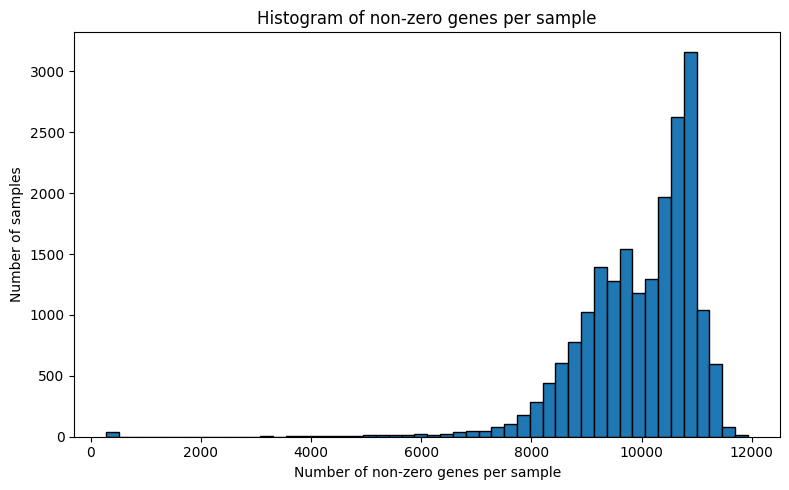

In [30]:
X = pseudo_bulk.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

## Disease classification - DiSignAtlas

In [26]:
dsa = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/DiSignAtlas/disignatlas.h5ad")

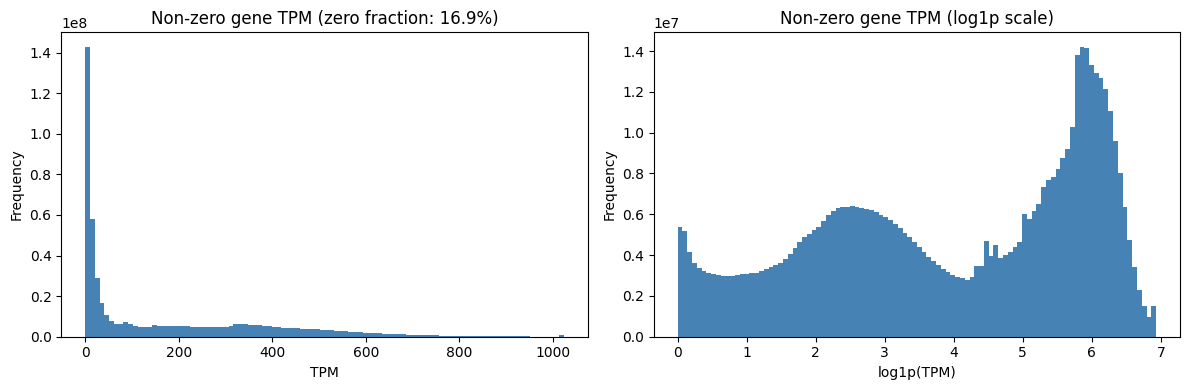

Sparsity: 16.9%
n_obs=54429, n_vars=11904
Non-zero value stats: min=0.00, median=69.42, max=1023.00
Fraction that are exactly 1: 0.0%


In [27]:
gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
dsa = dsa[:, dsa.var_names.isin(gene_list)].copy()

# Denormalize: stored as log2(TPM+1) → TPM
X = dsa.X
if sparse.issparse(X):
    X = X.toarray()
X = np.exp2(X.astype(np.float32)) - 1

vals = X[X > 0].ravel()
zero_frac = 1 - (np.count_nonzero(X) / X.size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("TPM")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene TPM (zero fraction: {zero_frac:.1%})")
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(TPM)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene TPM (log1p scale)")
plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={dsa.n_obs}, n_vars={dsa.n_vars}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [28]:
dsa.X.mean(axis = 1).mean()

4.727678

[9814 9843 9698 9440 9866 9864 9798 9876 9837 9901]
mean: 9897.784912454757
median: 10791.0
min: 3
max: 11679


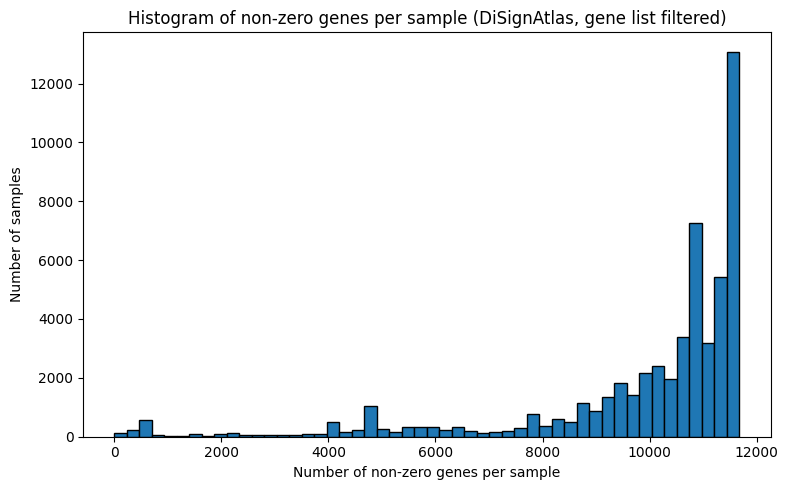

In [29]:
print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (DiSignAtlas, gene list filtered)")
plt.tight_layout()
plt.show()

del dsa

## Drug response prediction - GDSC

In [31]:
gdsc = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/GDSC/gdsc.h5ad")

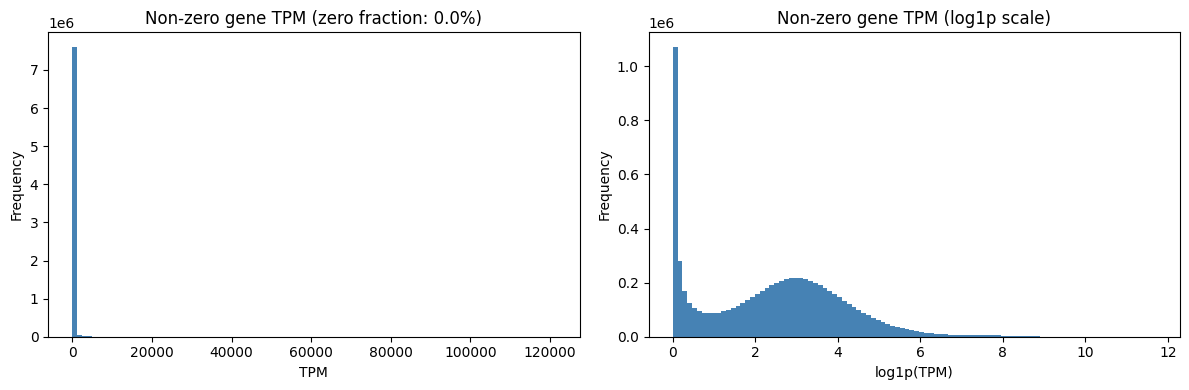

Sparsity: 0.0%
n_obs=700, n_vars=11954
Non-zero value stats: min=0.00, median=11.47, max=121334.91
Fraction that are exactly 1: 0.0%


In [32]:
gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
gdsc = gdsc[:, gdsc.var_names.isin(gene_list)].copy()

# Denormalize: assumed log2(TPM+1) → TPM (same as GDSC/CCLE standard)
X = gdsc.X
if sparse.issparse(X):
    X = X.toarray()
X = np.exp2(X.astype(np.float32)) - 1

vals = X[X > 0].ravel()
zero_frac = 1 - (np.count_nonzero(X) / X.size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("TPM")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene TPM (zero fraction: {zero_frac:.1%})")
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(TPM)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene TPM (log1p scale)")
plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={gdsc.n_obs}, n_vars={gdsc.n_vars}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [33]:
gdsc.X.mean(axis = 1).mean()

3.188793

[11954 11954 11954 11954 11954 11954 11954 11954 11954 11954]
mean: 11954.0
median: 11954.0
min: 11954
max: 11954


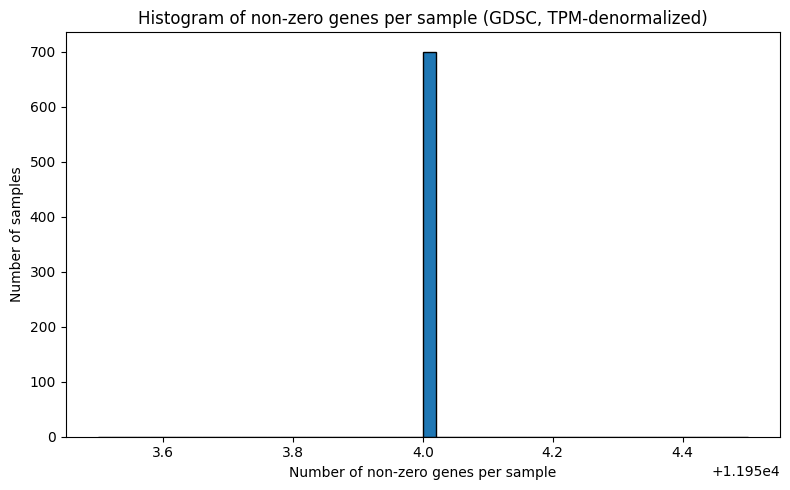

In [34]:
nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (GDSC, TPM-denormalized)")
plt.tight_layout()
plt.show()

del gdsc

## Gene essentiality prediction - DepMap

In [36]:
depmap = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/DepMap/depmap.h5ad")

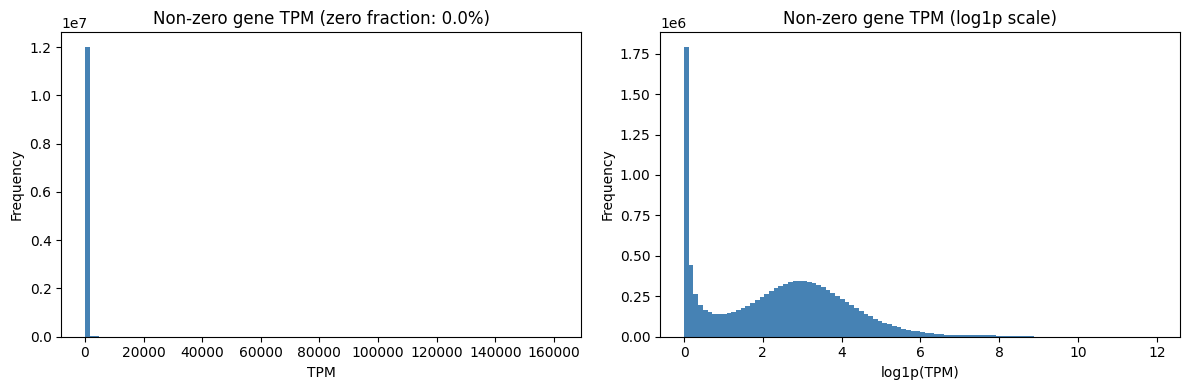

Sparsity: 0.0%
n_obs=1103, n_vars=11818
Non-zero value stats: min=0.0000, median=11.11, max=161132.97
Fraction that are exactly 1: 0.0%


In [37]:
gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
depmap = depmap[:, depmap.var_names.isin(gene_list)].copy()

# Expression is in the expr_array layer, not .X
X = depmap.layers["expr_array"]
if sparse.issparse(X):
    X = X.toarray()
X = np.exp2(X.astype(np.float32)) - 1

vals = X[X > 0].ravel()
zero_frac = 1 - (np.count_nonzero(X) / X.size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("TPM")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene TPM (zero fraction: {zero_frac:.1%})")
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(TPM)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene TPM (log1p scale)")
plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={depmap.n_obs}, n_vars={depmap.n_vars}")
print(f"Non-zero value stats: min={vals.min():.4f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [39]:
depmap.X.mean(axis = 1).mean()

3.192446430970241

[11818 11818 11818 11818 11818 11818 11818 11818 11818 11818]
mean: 11818.0
median: 11818.0
min: 11818
max: 11818


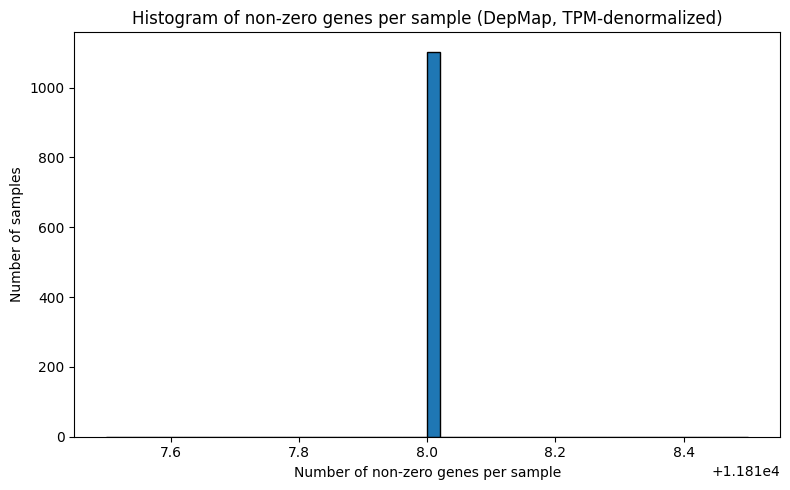

In [40]:
nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (DepMap, TPM-denormalized)")
plt.tight_layout()
plt.show()

del depmap

## Survival prediction - TCGA (SurvBoard)

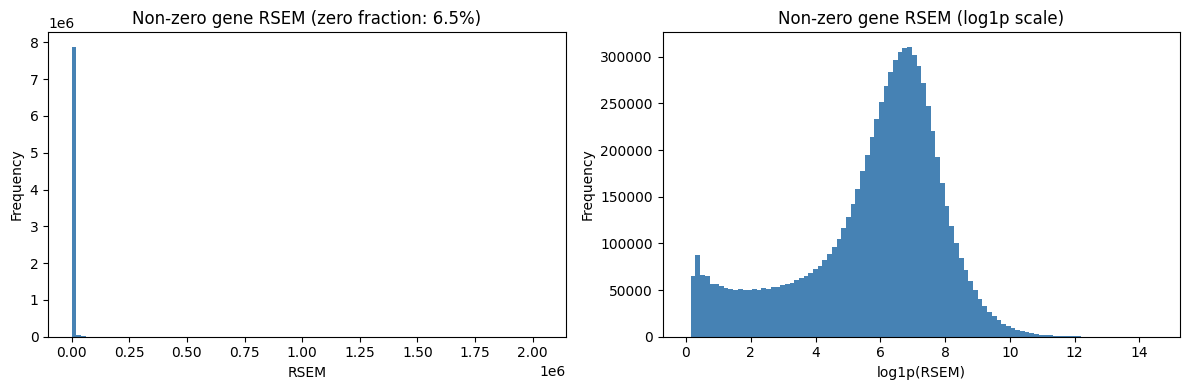

Sparsity: 6.5%
n_obs=771, n_vars=11003
Non-zero value stats: min=0.0027, median=533.85, max=2040900.88
Fraction that are exactly 1: 0.0%


In [45]:
df = pd.read_csv(
    "/cluster/work/boeva/eheiss/datasets/SurvBoard/data_reproduced/TCGA/BRCA_data_complete_modalities_preprocessed.csv",
    low_memory=False
)

gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
gene_list_set = set(gene_list)

gene_info = pd.read_csv("/cluster/work/boeva/eheiss/scbFM/data/bulkformer_gene_info.csv")
sym2ensg = gene_info.set_index("gene_symbol")["ensg_id"].to_dict()

gex_cols = [c for c in df.columns if c.startswith("gex_")]
hugo_symbols = [c[len("gex_"):].split("|")[0] for c in gex_cols]

# Keep only columns whose HUGO maps to an ENSG in gene_list
keep_cols = [col for col, sym in zip(gex_cols, hugo_symbols)
             if sym2ensg.get(sym) in gene_list_set]

X = df[keep_cols].values.astype(np.float32)

# Denormalize: stored as log2(RSEM+1) → RSEM
X = np.exp2(X) - 1

vals = X[X > 0].ravel()
zero_frac = 1 - (np.count_nonzero(X) / X.size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("RSEM")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene RSEM (zero fraction: {zero_frac:.1%})")
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(RSEM)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene RSEM (log1p scale)")
plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={X.shape[0]}, n_vars={X.shape[1]}")
print(f"Non-zero value stats: min={vals.min():.4f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [46]:
X.mean(axis=1).mean()

1397.408

[10319 10316 10470 10172 10359 10015 10409 10305 10363 10340]
mean: 10285.927367055772
median: 10304.0
min: 9759
max: 10780


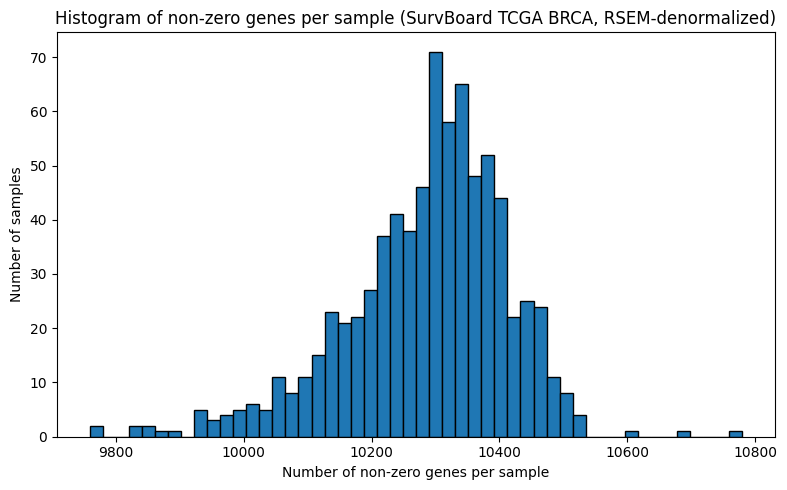

In [48]:
nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (SurvBoard TCGA BRCA, RSEM-denormalized)")
plt.tight_layout()
plt.show()
